In [1]:
import numpy as np

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [3]:
df=pd.read_csv(r"C:\Users\Administrator\Downloads\archive (2)\WA_Fn-UseC_-Telco-Customer-Churn.csv")
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
df['TotalCharges']=df['TotalCharges'].replace(" ","0")
df['TotalCharges']=df['TotalCharges'].astype("float")

In [6]:
df.isnull().sum().sum()

np.int64(0)

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df['customerID'].duplicated().sum()

np.int64(0)

In [10]:
# converted  0 and 1 values of senior citizen to Yes/No to make it easier to understands
def convert(value):
    if value==1:
        return "Yes"
    else :
        return "No"

df['SeniorCitizen']=df['SeniorCitizen'].apply(convert)


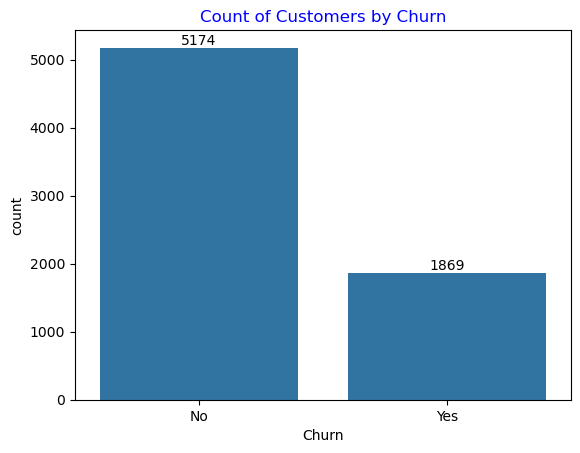

In [11]:
ax=sns.countplot(x='Churn',data=df)
ax.bar_label(ax.containers[0])
plt.title("Count of Customers by Churn",color="Blue")
plt.show()

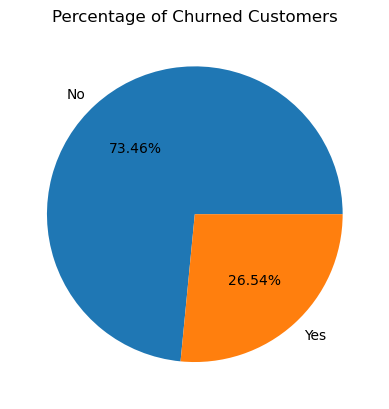

In [12]:
gb=df.groupby('Churn').agg({'Churn':'count'})
plt.pie(gb['Churn'],labels=gb.index,autopct="%1.2f%%")
plt.title("Percentage of Churned Customers",color="Black")
plt.show()

#from the given pie chart we can conclude that 26.54% of our customers have churned out.# not let's explore the reason behind it

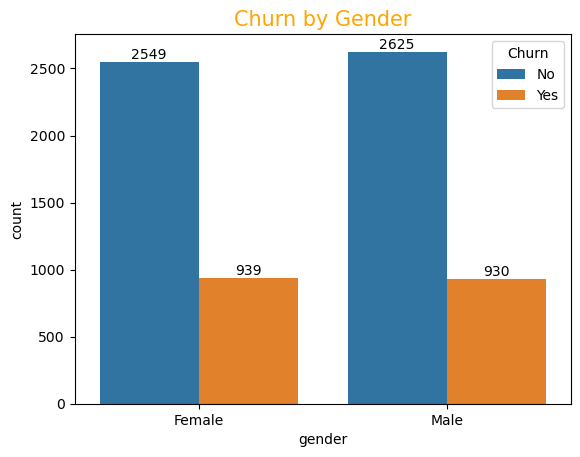

In [14]:
sn=sns.countplot(x='gender',data=df,hue='Churn')
sn.bar_label(sn.containers[0])
sn.bar_label(sn.containers[1])
plt.title('Churn by Gender',color='orange',fontsize=15)
plt.show()

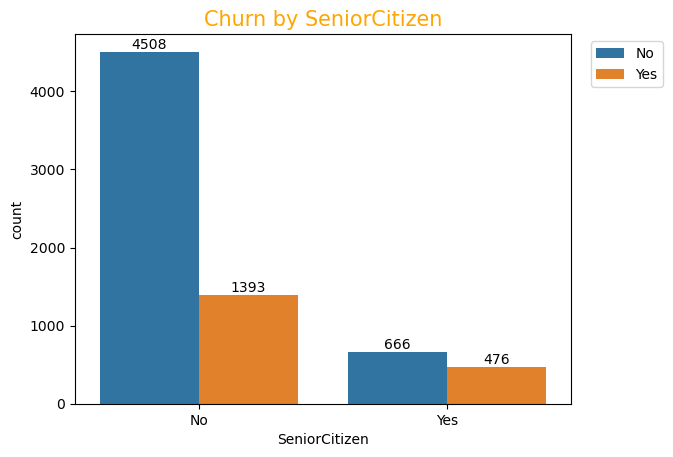

In [15]:
sn=sns.countplot(x='SeniorCitizen',data=df,hue='Churn')
sn.bar_label(sn.containers[0])
sn.bar_label(sn.containers[1])
plt.title('Churn by SeniorCitizen',color='orange',fontsize=15)
plt.legend(bbox_to_anchor =(1.2,1.))
plt.show()

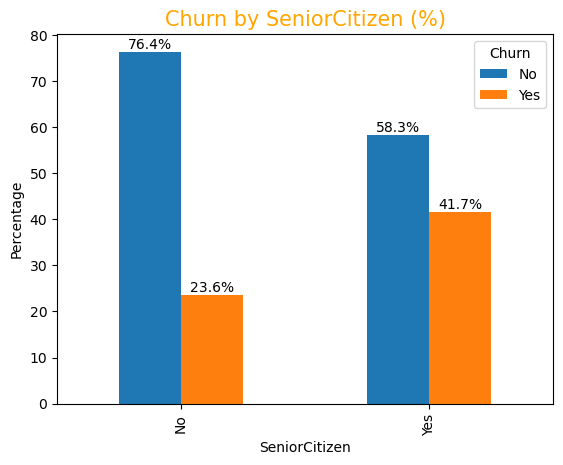

In [16]:
# create percentage table
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

ax = ct.plot(kind='bar')

# add labels
for container in ax.containers:
    labels = [f'{v.get_height():.1f}%' for v in container]
    ax.bar_label(container, labels=labels)

plt.title('Churn by SeniorCitizen (%)', color='orange', fontsize=15)
plt.ylabel('Percentage')
plt.show()

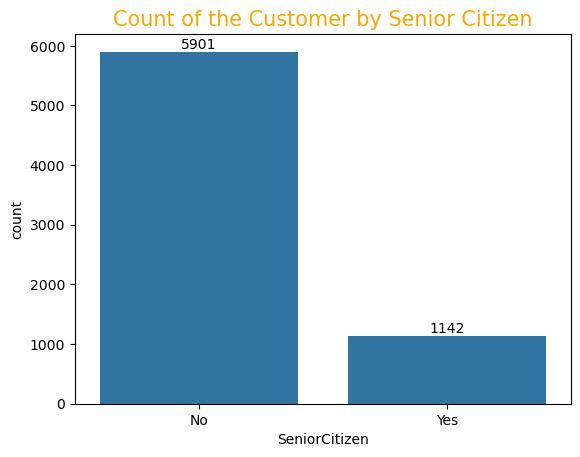

In [17]:
sn=sns.countplot(x='SeniorCitizen',data=df)
sn.bar_label(sn.containers[0])
plt.title('Count of the Customer by Senior Citizen',color='orange',fontsize=15)
plt.show()

#comparative a greated percentage of people in senior citizen category have churned

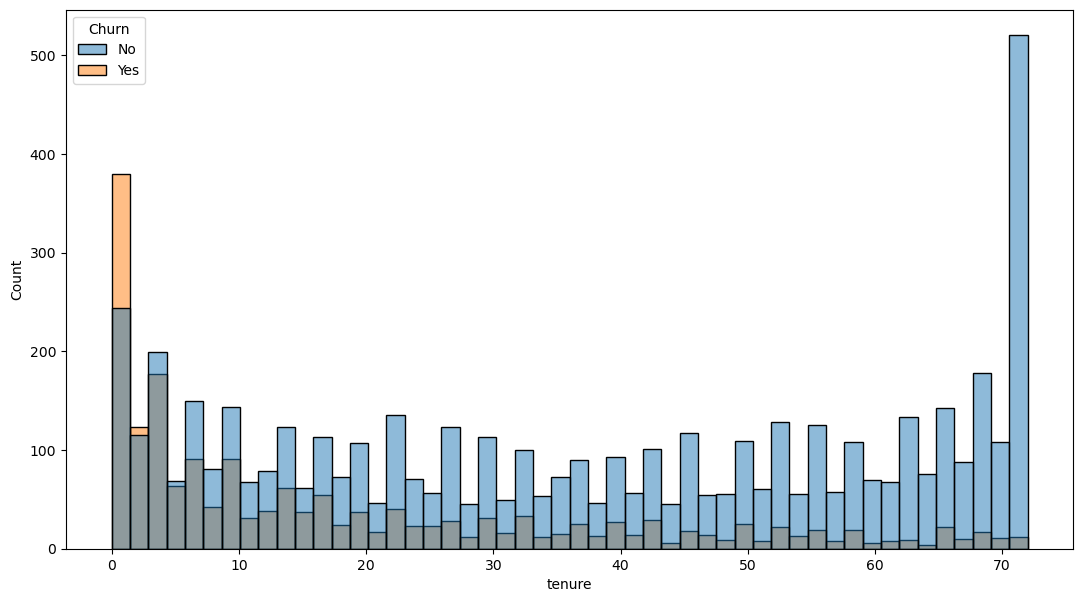

In [19]:
plt.figure(figsize=(13,7))
sns.histplot(x='tenure',data=df,hue='Churn',bins=50)
plt.show()

#people who have used our services for a long time stayed and people who have used our services
#1 or 2 months have churned

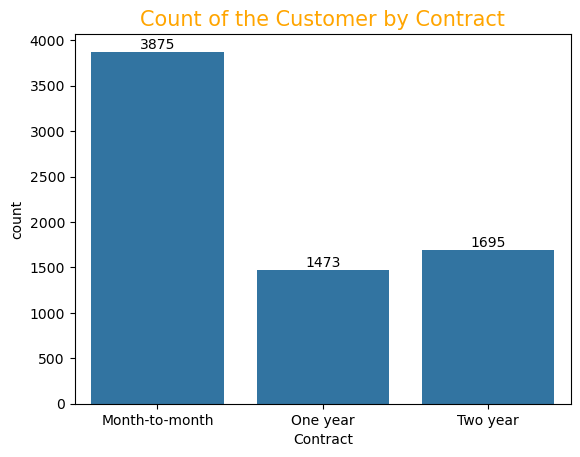

In [21]:
sn=sns.countplot(x='Contract',data=df)
sn.bar_label(sn.containers[0])
plt.title('Count of the Customer by Contract',color='orange',fontsize=15)
plt.show()

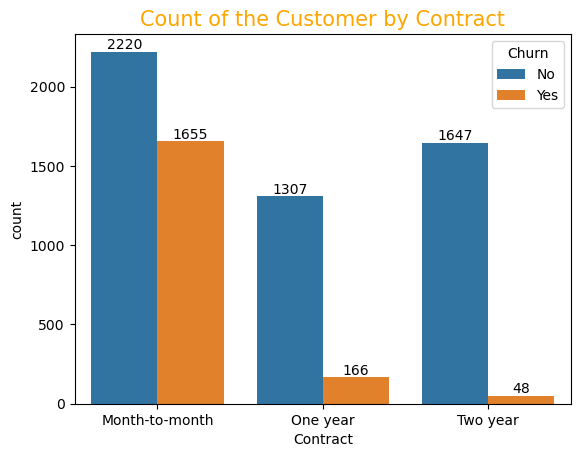

In [31]:
sn=sns.countplot(x='Contract',data=df,hue='Churn')
sn.bar_label(sn.containers[0])
sn.bar_label(sn.containers[1])
plt.title('Count of the Customer by Contract',color='orange',fontsize=15)
plt.show()

#people who have month to match contract are likely to churn then from those who have 1 and 2 year or contract.

In [32]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

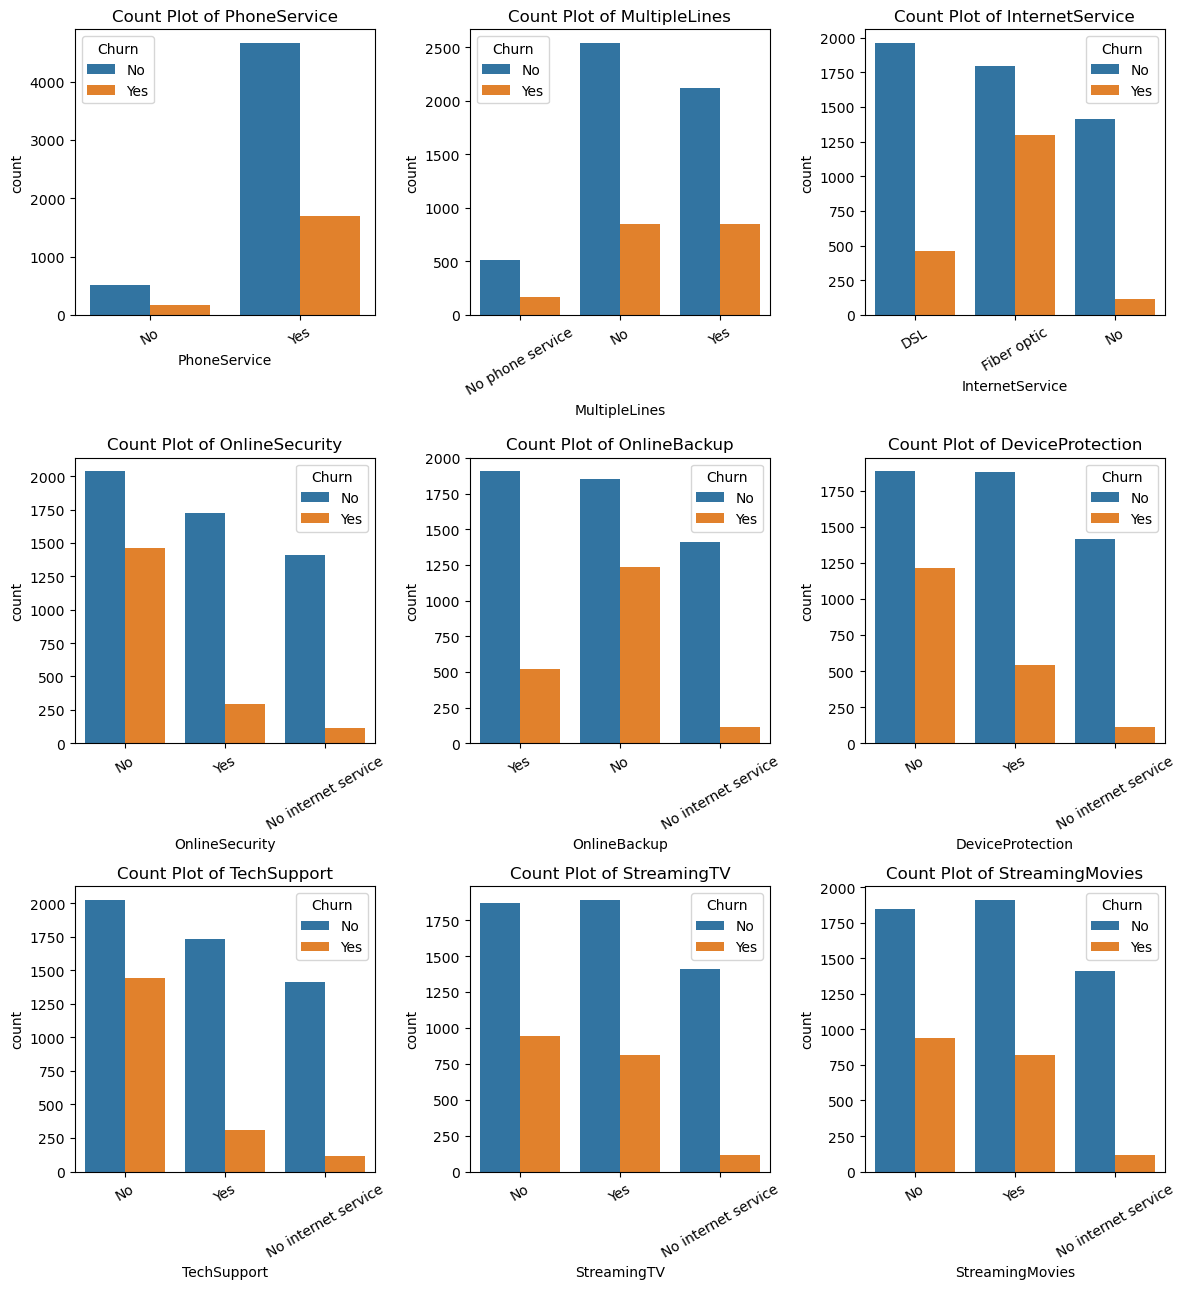

In [34]:


# column list
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# set figure size
plt.figure(figsize=(12, 13))

# loop through columns and create subplots
for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)   # 3x3 grid (since 9 columns)
    sns.countplot(x=col, data=df,hue ='Churn')
    plt.title(f'Count Plot of {col}')
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

#Most customers have phone and internet services, with fiber optic being a common internet type.
#Value-added services like online security, backup, and tech support are less frequently adopted compared to basic services.
#Streaming services (TV and movies) show moderate usage, indicating entertainment is important but not universal.

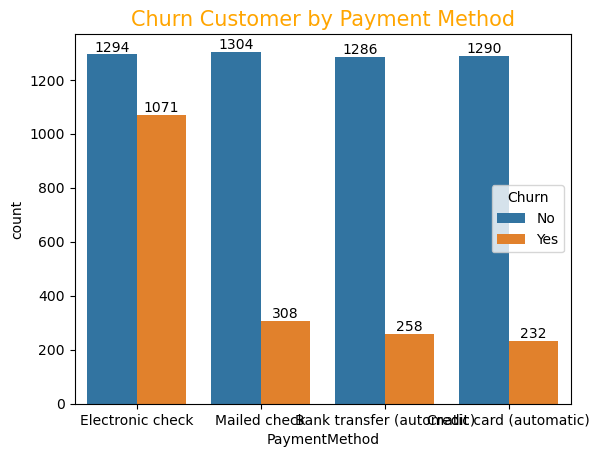

In [30]:
sn=sns.countplot(x='PaymentMethod',data=df,hue='Churn')
sn.bar_label(sn.containers[0])
sn.bar_label(sn.containers[1])
plt.title('Churn Customer by Payment Method',color='orange',fontsize=15)
plt.show()

#customer is likely to churn when  using electronic check as a payment method.